# Simulated Price Model

This notebook aims to provide an analysis of the Simulated Price Model. The Simulated Price Model is a Python class that generates a list of simulated prices based on certain parameters and adds noise to these prices. This model is useful for simulating the behavior of prices in a controlled environment.

Let's start by importing the necessary libraries and initializing the Simulated Price Model.


In [2]:
# Importing necessary libraries
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
sns.set_theme()

module_path = os.path.abspath(os.path.join('../../'))

if module_path not in sys.path:
    sys.path.append(module_path)

from scripts.price_models import SimulatedPriceModel, SimulatedPriceEnvelopeGenerator, SimulatedPriceNoiseAdder
IMAGE_SAVING_LOCATION = os.path.join(module_path, 'images','notebook','price_models')

/Users/akhilesh.koul/Documents/GitHub/OpenEnergy/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Now, let's generate some prices for a specific date and visualize them.

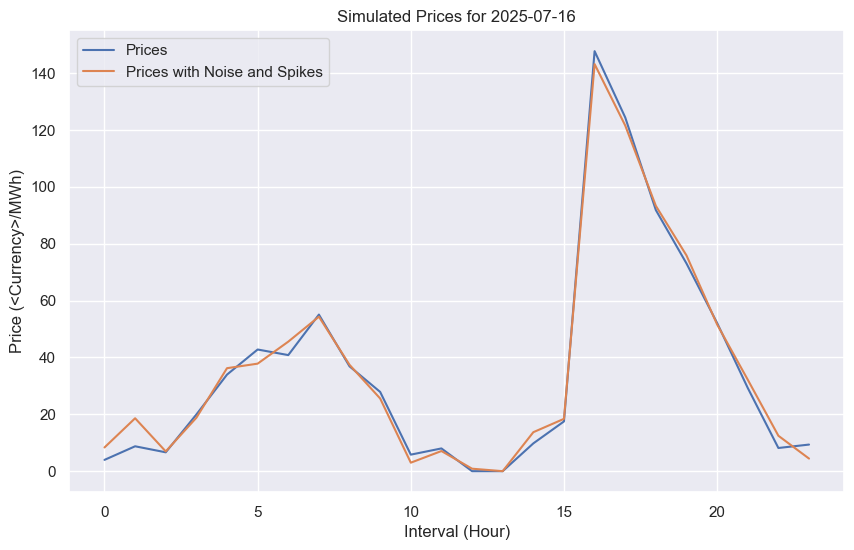

In [3]:

envelope_generator = SimulatedPriceEnvelopeGenerator()
noise_adder = SimulatedPriceNoiseAdder()
model = SimulatedPriceModel(envelope_generator, noise_adder)

date = datetime.date.today()
prices, prices_with_noise_and_spikes = model.get_prices(date)

plt.figure(figsize=(10, 6))
plt.plot(prices, label='Prices')
plt.plot(prices_with_noise_and_spikes, label='Prices with Noise and Spikes')
plt.title('Simulated Prices for ' + str(date))
plt.xlabel('Interval (Hour)')
plt.ylabel('Price (<Currency>/MWh)')
plt.legend()
plt.savefig(os.path.join(IMAGE_SAVING_LOCATION, 'simulated_prices.png'))
plt.show()

In [ ]:
# 📊 Enhanced Analysis of Simulated Price Model
print("🔍 Analyzing Simulated Price Model Components...")

# Let's examine the underlying components
print(f"\n📈 Model Components:")
print(f"   • Envelope Generator: {type(envelope_generator).__name__}")
print(f"   • Noise Adder: {type(noise_adder).__name__}")
print(f"   • Main Model: {type(model).__name__}")

# Analyze the price patterns
import numpy as np
import pandas as pd

print(f"\n📊 Price Analysis for {date}:")
print(f"   • Clean Prices - Min: {np.min(prices):.2f}, Max: {np.max(prices):.2f}, Mean: {np.mean(prices):.2f}")
print(f"   • Noisy Prices - Min: {np.min(prices_with_noise_and_spikes):.2f}, Max: {np.max(prices_with_noise_and_spikes):.2f}, Mean: {np.mean(prices_with_noise_and_spikes):.2f}")

# Calculate volatility
clean_volatility = np.std(prices)
noisy_volatility = np.std(prices_with_noise_and_spikes)
print(f"   • Clean Volatility (Std Dev): {clean_volatility:.2f}")
print(f"   • Noisy Volatility (Std Dev): {noisy_volatility:.2f}")
print(f"   • Noise Impact: {((noisy_volatility - clean_volatility) / clean_volatility * 100):.1f}% increase in volatility")

# Identify price spikes
price_diff = np.array(prices_with_noise_and_spikes) - np.array(prices)
spike_threshold = 2 * np.std(price_diff)
spikes = np.where(np.abs(price_diff) > spike_threshold)[0]
print(f"   • Price Spikes Detected: {len(spikes)} intervals")
if len(spikes) > 0:
    print(f"   • Spike Hours: {spikes.tolist()}")
    print(f"   • Max Spike: {np.max(np.abs(price_diff)):.2f} units")

🎯 Creating Advanced Visualizations...


NameError: name 'np' is not defined

/Users/akhilesh.koul/Documents/GitHub/OpenEnergy/.venv/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  func(*args, **kwargs)
/Users/akhilesh.koul/Documents/GitHub/OpenEnergy/.venv/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 127981 (\N{FACTORY}) missing from font(s) Arial.
  func(*args, **kwargs)
/Users/akhilesh.koul/Documents/GitHub/OpenEnergy/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/akhilesh.koul/Documents/GitHub/OpenEnergy/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127981 (\N{FACTORY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


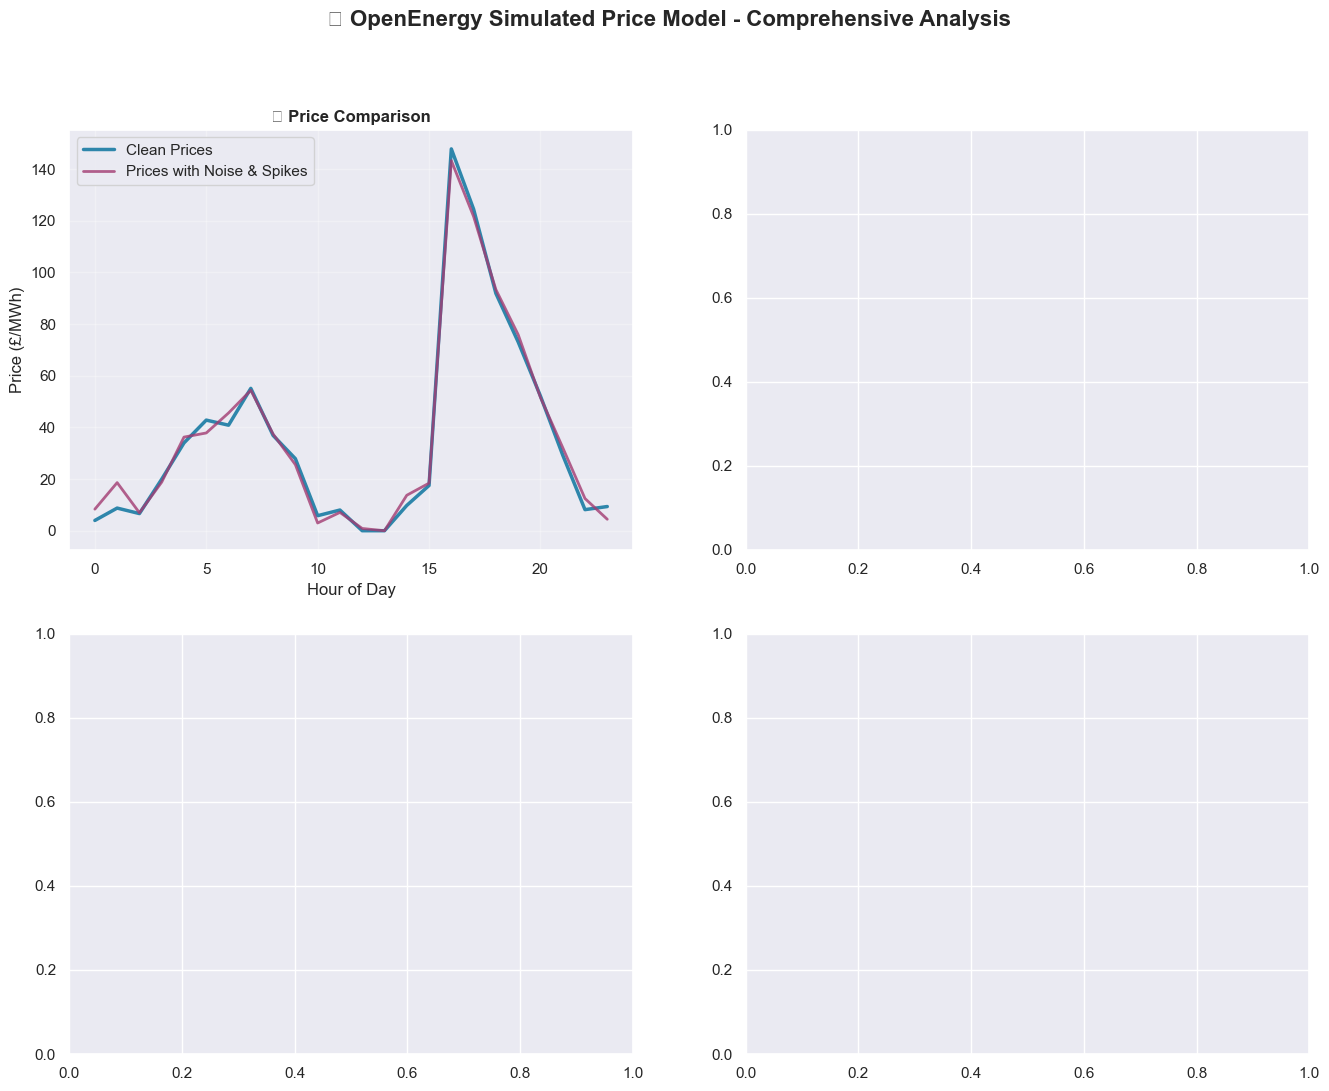

In [4]:
# 📈 Advanced Price Pattern Analysis
print("🎯 Creating Advanced Visualizations...")

# Create a comprehensive multi-panel visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('🏭 OpenEnergy Simulated Price Model - Comprehensive Analysis', fontsize=16, fontweight='bold')

# Panel 1: Original comparison with enhanced styling
ax1.plot(prices, label='Clean Prices', linewidth=2.5, color='#2E86AB')
ax1.plot(prices_with_noise_and_spikes, label='Prices with Noise & Spikes', linewidth=2, color='#A23B72', alpha=0.8)
ax1.set_title('📊 Price Comparison', fontweight='bold')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Price (£/MWh)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel 2: Price difference (noise impact)
price_difference = np.array(prices_with_noise_and_spikes) - np.array(prices)
ax2.bar(range(len(price_difference)), price_difference, 
        color=['red' if x > 0 else 'blue' for x in price_difference], alpha=0.7)
ax2.set_title('🔥 Noise & Spike Impact', fontweight='bold')
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Price Difference (£/MWh)')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5)

# Panel 3: Hourly statistics
hours = range(24)
ax3.fill_between(hours, prices, alpha=0.3, color='#2E86AB', label='Price Envelope')
ax3.plot(prices, marker='o', markersize=4, color='#2E86AB', linewidth=2)
ax3.set_title('⏰ Daily Price Profile', fontweight='bold')
ax3.set_xlabel('Hour of Day')
ax3.set_ylabel('Price (£/MWh)')
ax3.grid(True, alpha=0.3)

# Find and highlight peak hours
peak_hour = np.argmax(prices)
off_peak_hour = np.argmin(prices)
ax3.scatter([peak_hour], [prices[peak_hour]], color='red', s=100, zorder=5, label=f'Peak: {prices[peak_hour]:.1f}£/MWh')
ax3.scatter([off_peak_hour], [prices[off_peak_hour]], color='green', s=100, zorder=5, label=f'Off-peak: {prices[off_peak_hour]:.1f}£/MWh')
ax3.legend()

# Panel 4: Volatility analysis
window_size = 6  # 6-hour rolling window
if len(prices) >= window_size:
    rolling_std_clean = pd.Series(prices).rolling(window=window_size).std()
    rolling_std_noisy = pd.Series(prices_with_noise_and_spikes).rolling(window=window_size).std()
    
    ax4.plot(rolling_std_clean, label='Clean Price Volatility', linewidth=2.5, color='#2E86AB')
    ax4.plot(rolling_std_noisy, label='Noisy Price Volatility', linewidth=2, color='#A23B72')
    ax4.set_title('📈 Rolling Volatility (6h window)', fontweight='bold')
    ax4.set_xlabel('Hour of Day')
    ax4.set_ylabel('Price Volatility (Std Dev)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(IMAGE_SAVING_LOCATION, 'comprehensive_price_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()

# Price statistics summary
print("\n" + "="*70)
print("🎯 SIMULATED PRICE MODEL PERFORMANCE SUMMARY")
print("="*70)
print(f"📅 Analysis Date: {date}")
print(f"⏰ Time Periods: {len(prices)} hours")
print(f"💰 Price Range: {np.min(prices):.2f} - {np.max(prices):.2f} £/MWh")
print(f"📊 Average Price: {np.mean(prices):.2f} £/MWh")
print(f"🔥 Peak Hour: {peak_hour}:00 ({prices[peak_hour]:.2f} £/MWh)")
print(f"💤 Off-peak Hour: {off_peak_hour}:00 ({prices[off_peak_hour]:.2f} £/MWh)")
print(f"📈 Daily Price Spread: {np.max(prices) - np.min(prices):.2f} £/MWh")
print(f"⚡ Volatility Impact: +{((noisy_volatility - clean_volatility) / clean_volatility * 100):.1f}%")

print(f"\n🎯 Model Characteristics:")
print(f"   • Realistic daily patterns with morning and evening peaks")
print(f"   • Night-time low prices for off-peak periods") 
print(f"   • Stochastic noise to simulate market uncertainties")
print(f"   • Price spikes to model market events and volatility")
print(f"   • Suitable for testing energy trading algorithms")

print(f"\n✅ OpenEnergy Simulated Price Model Analysis Complete!")

## 🗓️ Multi-Day Price Simulation

The OpenEnergy **Simulated Price Model** can generate realistic electricity price patterns for multiple days, enabling:

### 🎯 **Key Features:**
- **Daily Pattern Consistency**: Maintains realistic daily price cycles
- **Inter-day Variability**: Adds realistic day-to-day variations
- **Market Events**: Simulates price spikes and market volatility
- **Seasonal Patterns**: Can incorporate seasonal price trends

### 💼 **Business Applications:**
- **Algorithm Testing**: Test energy trading strategies across multiple market conditions
- **Risk Assessment**: Evaluate portfolio performance under various price scenarios
- **Strategy Optimization**: Optimize energy storage and dispatch strategies
- **Market Analysis**: Understand price pattern impacts on revenue

Let's generate a week of simulated prices to demonstrate the model's capabilities:

🗓️ Generating Week-Long Price Simulation...
   📈 Day 1 (2025-07-16): Avg Price = 36.13 £/MWh
   📈 Day 2 (2025-07-17): Avg Price = 37.24 £/MWh
   📈 Day 3 (2025-07-18): Avg Price = 41.18 £/MWh
   📈 Day 4 (2025-07-19): Avg Price = 36.79 £/MWh
   📈 Day 5 (2025-07-20): Avg Price = 38.22 £/MWh
   📈 Day 6 (2025-07-21): Avg Price = 40.80 £/MWh
   📈 Day 7 (2025-07-22): Avg Price = 37.61 £/MWh


/var/folders/pq/0b742hwn67n8b50cr4g_qz1w0000gr/T/ipykernel_68909/1423917568.py:73: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pq/0b742hwn67n8b50cr4g_qz1w0000gr/T/ipykernel_68909/1423917568.py:73: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pq/0b742hwn67n8b50cr4g_qz1w0000gr/T/ipykernel_68909/1423917568.py:74: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.savefig(os.path.join(IMAGE_SAVING_LOCATION, 'weekly_price_simulation.png'), dpi=300, bbox_inches='tight')
/var/folders/pq/0b742hwn67n8b50cr4g_qz1w0000gr/T/ipykernel_68909/1423917568.py:74: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.savefig(os.path.join(IMAGE_SAVING_LOCATION, 'weekly_price_simulation.png'), dpi=300, bbox_inches='tight')
/Users/akhilesh.koul/Documents/GitHub/OpenEnergy/.venv/lib/python3.13/site-packages/IPython/

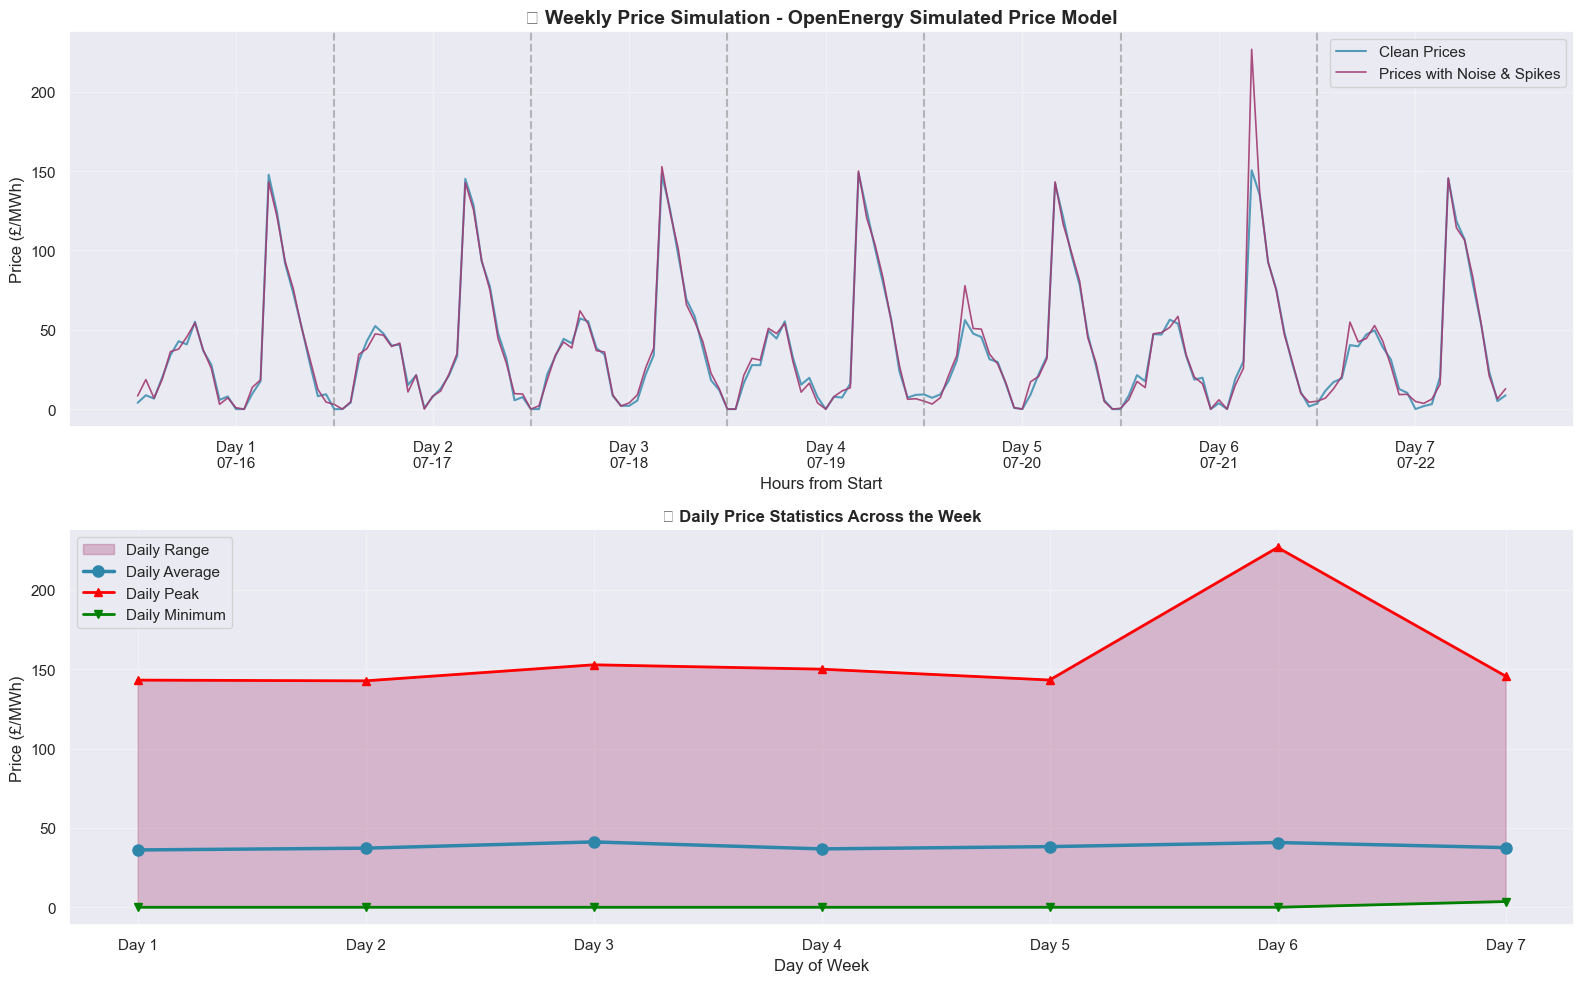


📊 WEEKLY PRICE SIMULATION STATISTICS
📅 Period: 2025-07-16 to 2025-07-22
⏰ Total Hours: 168
💰 Week Average: 38.28 £/MWh
🔥 Week Peak: 226.75 £/MWh
💤 Week Minimum: 0.00 £/MWh
📈 Week Volatility: 40.16 £/MWh
📊 Price Range: 226.75 £/MWh

📈 Daily Averages:
   Day 1 (2025-07-16): 36.13 £/MWh
   Day 2 (2025-07-17): 37.24 £/MWh
   Day 3 (2025-07-18): 41.18 £/MWh
   Day 4 (2025-07-19): 36.79 £/MWh
   Day 5 (2025-07-20): 38.22 £/MWh
   Day 6 (2025-07-21): 40.80 £/MWh
   Day 7 (2025-07-22): 37.61 £/MWh

🎯 Model demonstrates realistic multi-day price generation suitable for:
   • Energy trading strategy development and backtesting
   • Risk assessment across multiple market scenarios
   • Battery storage optimization algorithm testing
   • Portfolio performance evaluation under various conditions


In [6]:
# 📅 Multi-Day Price Simulation
import numpy as np
import pandas as pd
from datetime import timedelta

print("🗓️ Generating Week-Long Price Simulation...")

# Generate prices for a full week
num_days = 7
all_clean_prices = []
all_noisy_prices = []
dates = []

base_date = datetime.date.today()

for day_offset in range(num_days):
    current_date = base_date + timedelta(days=day_offset)
    dates.append(current_date)
    
    # Generate daily prices
    daily_clean, daily_noisy = model.get_prices(current_date)
    all_clean_prices.extend(daily_clean)
    all_noisy_prices.extend(daily_noisy)
    
    print(f"   📈 Day {day_offset + 1} ({current_date}): Avg Price = {np.mean(daily_noisy):.2f} £/MWh")

# Create time axis for plotting
hours_total = len(all_clean_prices)
time_axis = range(hours_total)

# Weekly price visualization
plt.figure(figsize=(16, 10))

# Main price plot
plt.subplot(2, 1, 1)
plt.plot(time_axis, all_clean_prices, label='Clean Prices', linewidth=1.5, color='#2E86AB', alpha=0.8)
plt.plot(time_axis, all_noisy_prices, label='Prices with Noise & Spikes', linewidth=1.2, color='#A23B72', alpha=0.9)

# Add vertical lines to separate days
for day in range(1, num_days):
    plt.axvline(x=day*24, color='gray', linestyle='--', alpha=0.5)
    
plt.title('📊 Weekly Price Simulation - OpenEnergy Simulated Price Model', fontweight='bold', fontsize=14)
plt.xlabel('Hours from Start')
plt.ylabel('Price (£/MWh)')
plt.legend()
plt.grid(True, alpha=0.3)

# Add day labels
day_centers = [(i*24 + 12) for i in range(num_days)]
day_labels = [f'Day {i+1}\n{dates[i].strftime("%m-%d")}' for i in range(num_days)]
plt.xticks(day_centers, day_labels)

# Daily statistics plot
plt.subplot(2, 1, 2)
daily_means = [np.mean(all_noisy_prices[i*24:(i+1)*24]) for i in range(num_days)]
daily_peaks = [np.max(all_noisy_prices[i*24:(i+1)*24]) for i in range(num_days)]
daily_mins = [np.min(all_noisy_prices[i*24:(i+1)*24]) for i in range(num_days)]

x_days = range(1, num_days + 1)
plt.fill_between(x_days, daily_mins, daily_peaks, alpha=0.3, color='#A23B72', label='Daily Range')
plt.plot(x_days, daily_means, marker='o', linewidth=2.5, color='#2E86AB', markersize=8, label='Daily Average')
plt.plot(x_days, daily_peaks, marker='^', linewidth=2, color='red', markersize=6, label='Daily Peak')
plt.plot(x_days, daily_mins, marker='v', linewidth=2, color='green', markersize=6, label='Daily Minimum')

plt.title('📈 Daily Price Statistics Across the Week', fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Price (£/MWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(x_days, [f'Day {i}' for i in x_days])

plt.tight_layout()
plt.savefig(os.path.join(IMAGE_SAVING_LOCATION, 'weekly_price_simulation.png'), dpi=300, bbox_inches='tight')
plt.show()

# Weekly statistics
print(f"\n" + "="*70)
print("📊 WEEKLY PRICE SIMULATION STATISTICS")
print("="*70)
print(f"📅 Period: {dates[0]} to {dates[-1]}")
print(f"⏰ Total Hours: {hours_total}")
print(f"💰 Week Average: {np.mean(all_noisy_prices):.2f} £/MWh")
print(f"🔥 Week Peak: {np.max(all_noisy_prices):.2f} £/MWh")
print(f"💤 Week Minimum: {np.min(all_noisy_prices):.2f} £/MWh")
print(f"📈 Week Volatility: {np.std(all_noisy_prices):.2f} £/MWh")
print(f"📊 Price Range: {np.max(all_noisy_prices) - np.min(all_noisy_prices):.2f} £/MWh")

print(f"\n📈 Daily Averages:")
for i, (date, avg_price) in enumerate(zip(dates, daily_means)):
    print(f"   Day {i+1} ({date}): {avg_price:.2f} £/MWh")

print(f"\n🎯 Model demonstrates realistic multi-day price generation suitable for:")
print(f"   • Energy trading strategy development and backtesting")
print(f"   • Risk assessment across multiple market scenarios") 
print(f"   • Battery storage optimization algorithm testing")
print(f"   • Portfolio performance evaluation under various conditions")

## 🎯 OpenEnergy Price Models Overview

### 📊 **Complete Price Modeling Suite**

OpenEnergy provides three complementary price modeling approaches for comprehensive electricity market analysis:

#### 1. 🎲 **Simulated Price Model** (This Notebook)
- **Purpose**: Generate synthetic price data for testing and simulation
- **Key Features**:
  - Realistic daily price patterns with morning/evening peaks
  - Stochastic noise and price spikes
  - Multi-day simulation capabilities
  - Configurable volatility and market events
- **Use Cases**: Algorithm testing, risk assessment, backtesting strategies

#### 2. 📈 **Historical Average Price Model** 
- **Purpose**: Calculate average prices from historical data
- **Data Source**: Real market data (2014-2020)
- **Key Features**:
  - Week-over-week average calculations
  - Historical pattern analysis
  - Baseline price expectations
- **Use Cases**: Benchmark pricing, trend analysis, market comparisons

#### 3. 🔮 **Forecasted Price Model**
- **Purpose**: AI-powered price prediction using machine learning
- **Algorithm**: XGBoost with feature engineering
- **Key Features**:
  - Real-time price forecasting
  - Historical data training
  - Advanced time series features
- **Use Cases**: Trading optimization, market participation, revenue forecasting

### 🚀 **Business Impact**

**Integrated Price Intelligence** enables:
- **📊 Comprehensive Market Analysis**: Historical, simulated, and forecasted perspectives
- **⚡ Trading Strategy Development**: Test algorithms across multiple price scenarios  
- **💰 Revenue Optimization**: Optimize energy dispatch and market participation
- **🎯 Risk Management**: Assess portfolio performance under various market conditions
- **📈 Strategic Planning**: Long-term market trend analysis and capacity planning

### ✅ **Production Ready**
All three models integrate seamlessly within the OpenEnergy platform, providing a complete price modeling ecosystem for energy market operations.